линейные: F1, F2, F3, F4, F5, F7, F8, F9
нелинейные: F6 из-за модуля
инвариантные во времени: все (первые 6 без зав-ти от времени тоже)


In [223]:
using Plots
# F1: y1(n) = x(n)
function F1(x)
    return x
end

# F2: y2(n) = (1/5) * Σ(x(n-i) для i=0:5
function F2(x)
    y = zeros(length(x))
    for n in 1:length(x)
        for i in 0:5
            if n - i >= 1
                y[n] += (1/5) * x[n - i]
            end
        end
    end
    return y
end

# F3: y3(n) = -(1/4)*x(n)
function F3(x)
    return -(1/4) .* x
end

# F4: y4(n) = x(n-4)
function F4(x)
    y = zeros(length(x))
    for n in 1:length(x)
        if n - 4 >= 1
            y[n] = x[n - 4]
        end
    end
    return y
end

# F5: y5(n) = 2*y(n-1) + x(n)
function F5(x)
    y = zeros(length(x))
    for n in 1:length(x)
        y[n] = x[n]
        if n > 1
            y[n] += 2 * y[n - 1]
        end
    end
    return y
end

# F6: y6(n) = (1/2)*|x(n)|
function F6(x)
    return (1/2) .* abs.(x)
end

F6 (generic function with 1 method)

In [224]:
# F7: y7(n) = ∑bix(n−i) для i=0:30
function F7(x)

    b = [-0.026,-0.6,-0.017,-0.01,-0.022,-0.015,-0.03,-0.023,-0.041,
        -0.036,-0.059,-0.059,-0.094,-0.117,-0.218,-0.629,0.629,0.218,
        0.117,0.094,0.059,0.059,0.036,0.041,0.023,0.03,0.015,0.022,
        0.01,0.017,0.6,0.026]
    y = zeros(length(x))
    for n in 1:length(x)
        for i in 0:length(b)-1
            if n - i >= 1
                y[n] += b[i+1] * x[n - i]
            end
        end
    end
    return y
end

# F8: y8(n) = ∑bi*x(n−i)−∑ai*y(n−i) i=0:5 и i=1:5
function F8(x)
    b=[0.0646,-0.1235,0.1949,-0.1949,0.1235,-0.0646]
    a=[1.0000+0.0000im,1.4576-0.1880im,2.3598-0.2122im,1.8195-0.1694im,
        1.0772-0.0556im,0.3218+0.0000im]

    y = zeros(Complex, length(x))
    for n in 1:length(x)
        for i in 0:length(b)-1
            if n - i >= 1
                y[n] += b[i+1] * x[n - i]
            end
        end
        for i in 1:length(a)-1
            if n - i >= 1
                y[n] -= a[i+1] * y[n - i]
            end
        end
        y[n] /= a[1]
    end
    return y
end

# F9: y9(n) = ∑bi*x(n−i)−∑ai*y(n−i) i=0:5 и i=1:5
function F9(x)
    b=[0.0646,-0.1235,0.1949,-0.1949,0.1235,-0.0646]
    a=[1.0000,1.4277,2.1448,1.5880,0.9051,0.2682]

    y = zeros(length(x))
    for n in 1:length(x)
        for i in 0:length(b)-1
            if n - i >= 1
                y[n] += b[i+1] * x[n - i]
            end
        end
        for i in 1:length(a)-1
            if n - i >= 1
                y[n] -= a[i+1] * y[n - i]
            end
        end
        y[n] /= a[1]
    end
    return y
end

F9 (generic function with 1 method)

In [225]:
function delta(n_max)
    delta = zeros(n_max)
    delta[1] = 1  #(0) = 1
    return delta
end

function scatter_impulse(h, title, label)
    p = scatter(h, title="Импульсная характеристика " * title, label=label, linewidth=2, xlabel="n",
    markersize = 6,markerstrokewidth = 0,
    ylabel="h[n]", color=:darkolivegreen4)
    display(p)
end

function plot_impulse(h, title, label)
    p = plot(h, title="Импульсная характеристика " * title, label=label, linewidth=2, xlabel="n",
    markerstrokewidth = 0, ylabel="h[n]", color=:darkolivegreen4)
    display(p)
end

plot_impulse (generic function with 1 method)

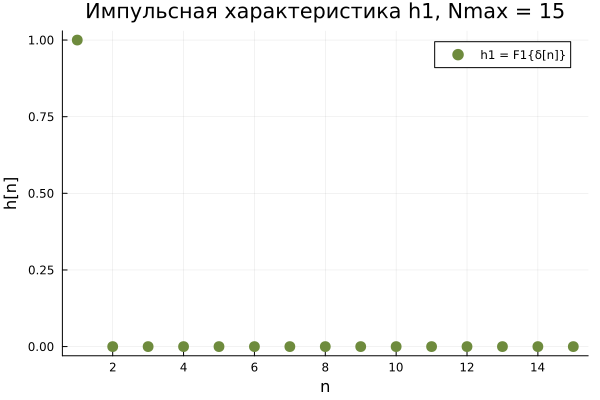

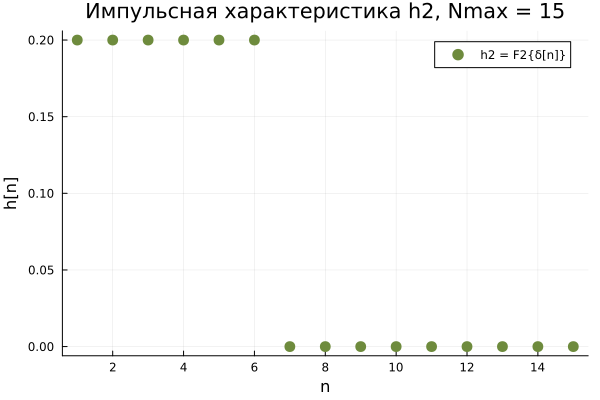

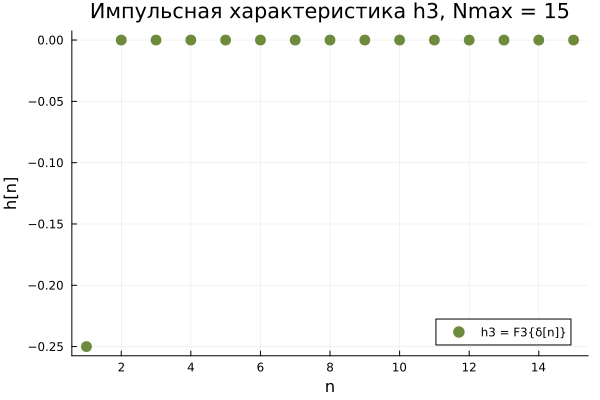

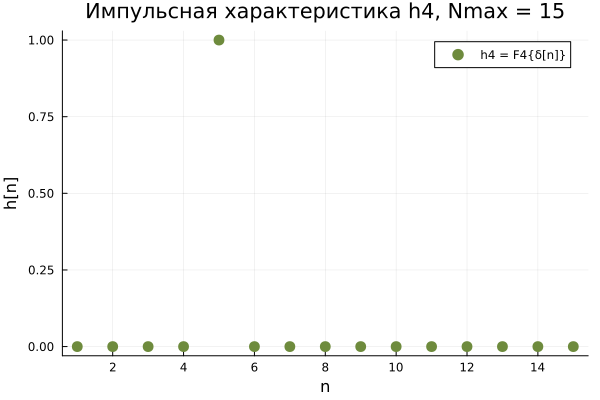

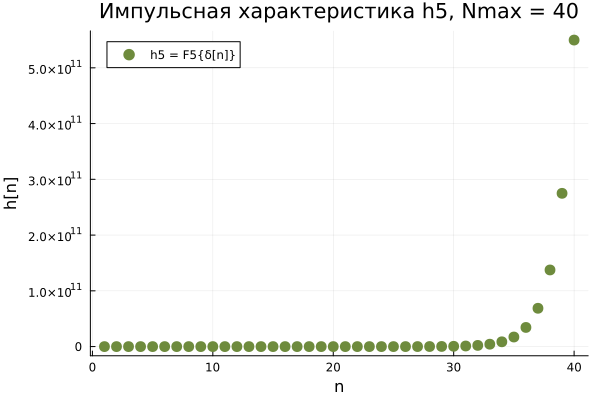

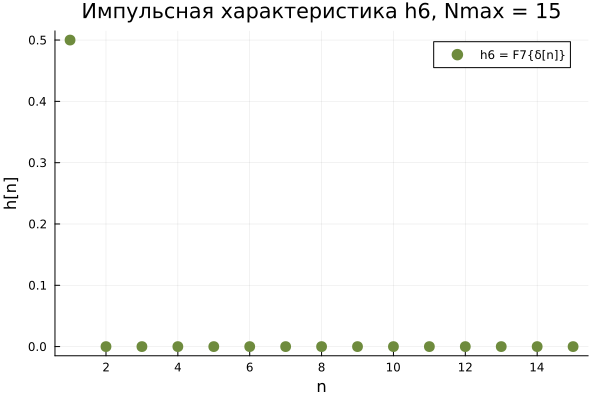

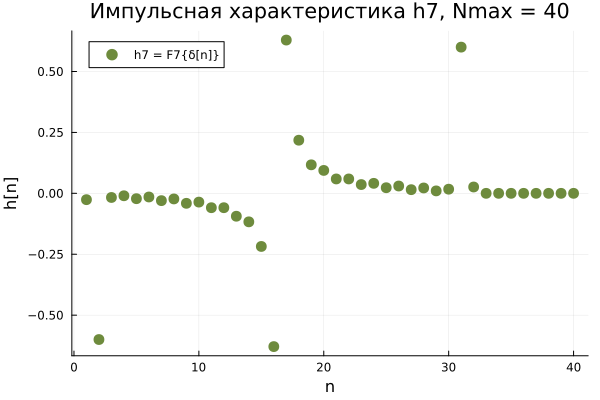

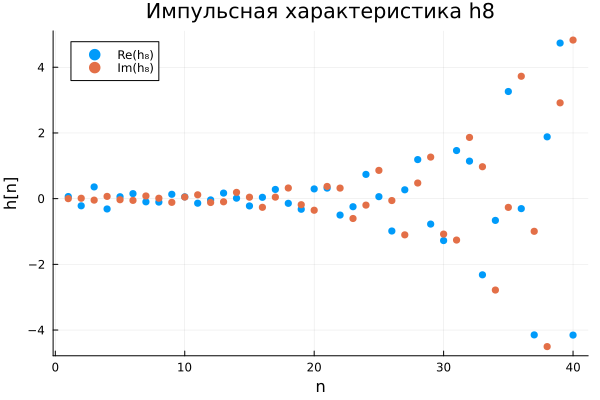

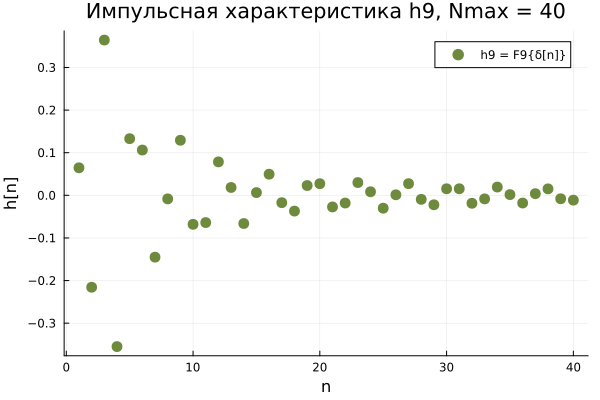

In [226]:
delta_15 = delta(15)
delta_40 = delta(40)

h1 = F1(delta_15)
h2 = F2(delta_15)
h3 = F3(delta_15)
h4 = F4(delta_15)
h5 = F5(delta_40)
h6 = F6(delta_15)

scatter_impulse(h1,"h1, Nmax = 15", "h1 = F1{δ[n]}")
scatter_impulse(h2,"h2, Nmax = 15", "h2 = F2{δ[n]}")
scatter_impulse(h3,"h3, Nmax = 15", "h3 = F3{δ[n]}")
scatter_impulse(h4,"h4, Nmax = 15", "h4 = F4{δ[n]}")
scatter_impulse(h5,"h5, Nmax = 40", "h5 = F5{δ[n]}")
scatter_impulse(h6,"h6, Nmax = 15", "h6 = F7{δ[n]}")

h7 = F7(delta_40)
h8 = F8(delta_40)
h9 = F9(delta_40)

scatter_impulse(h7,"h7, Nmax = 40", "h7 = F7{δ[n]}")
p=scatter(real.(h8), label="Re(h₈)",markerstrokewidth = 0, title="Импульсная характеристика h8",
ylabel="h[n]",xlabel="n")
scatter!(imag.(h8), label="Im(h₈)",markerstrokewidth = 0)
display(p)
# scatter_impulse(h8,"h8, Nmax = 40", "h8 = F8{δ[n]}")
scatter_impulse(h9,"h9, Nmax = 40", "h9 = F9{δ[n]}")


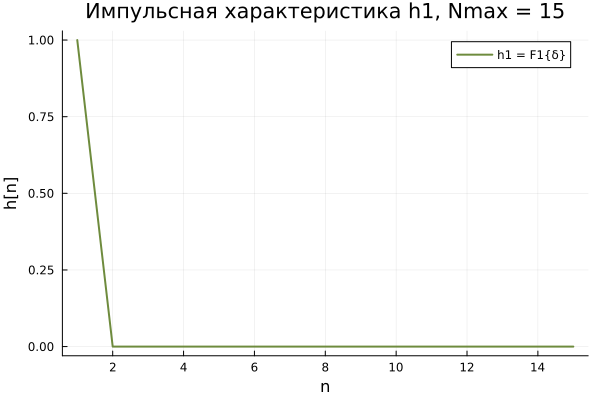

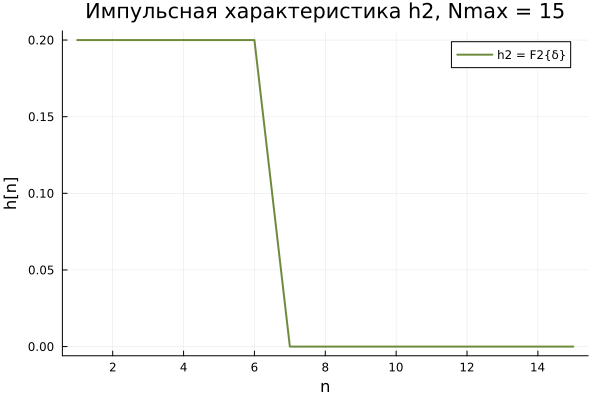

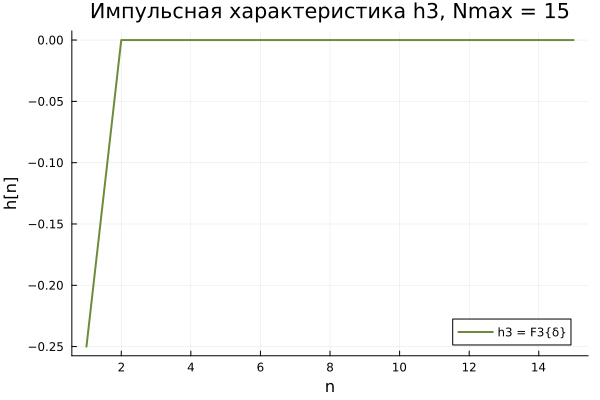

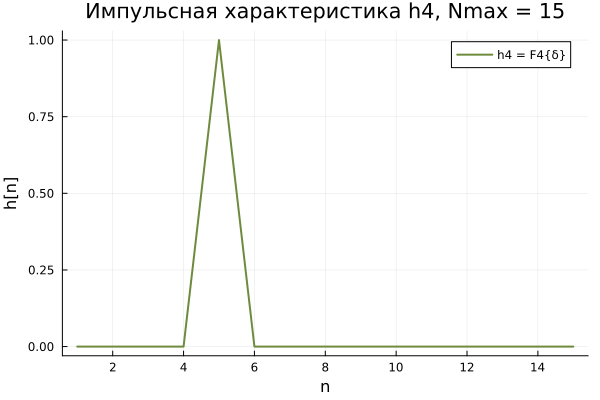

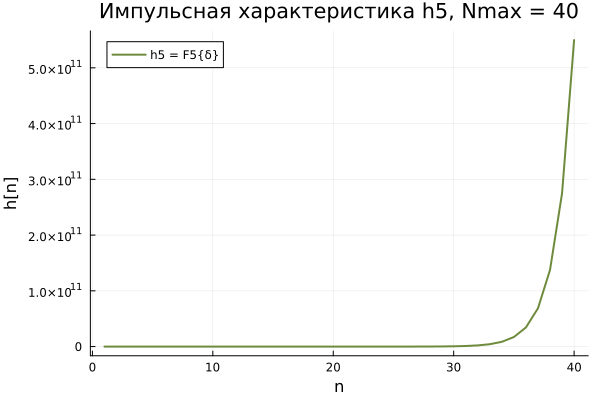

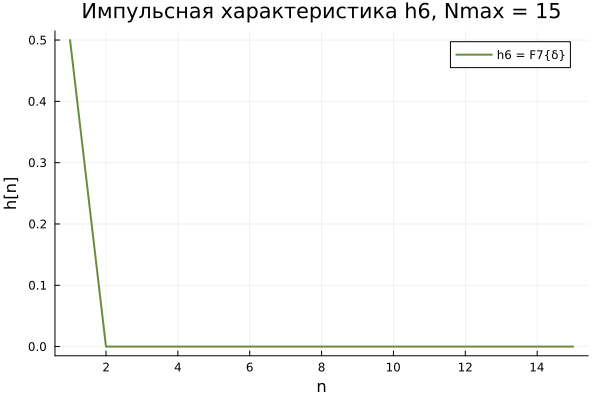

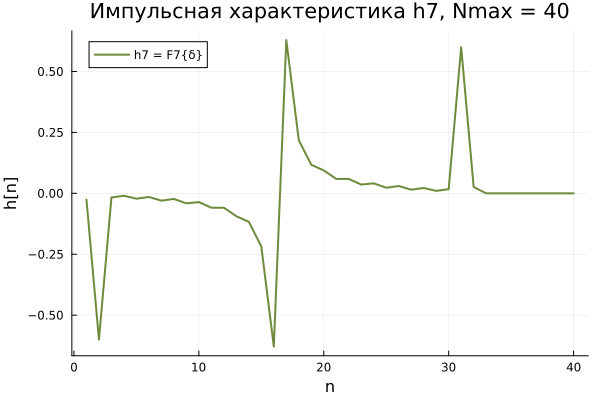

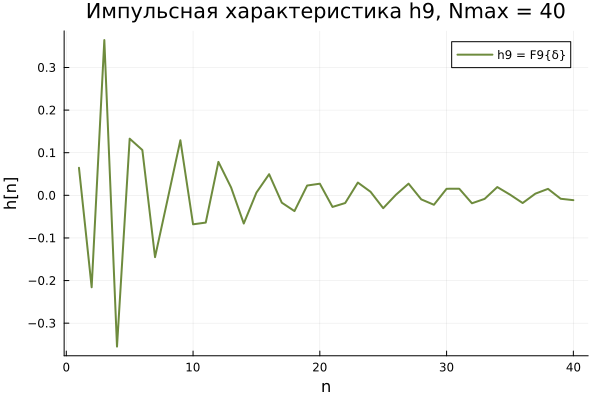

In [227]:
plot_impulse(h1,"h1, Nmax = 15", "h1 = F1{δ}")
plot_impulse(h2,"h2, Nmax = 15", "h2 = F2{δ}")
plot_impulse(h3,"h3, Nmax = 15", "h3 = F3{δ}")
plot_impulse(h4,"h4, Nmax = 15", "h4 = F4{δ}")
plot_impulse(h5,"h5, Nmax = 40", "h5 = F5{δ}")
plot_impulse(h6,"h6, Nmax = 15", "h6 = F7{δ}")

plot_impulse(h7,"h7, Nmax = 40", "h7 = F7{δ}")
# plot_impulse(h8,"h8, Nmax = 40", "h8 = F8{δ}")
plot_impulse(h9,"h9, Nmax = 40", "h9 = F9{δ}")

In [228]:
function check_stability(h, name)
    sum_h = sum(abs.(h))
    is_stable = sum_h < Inf && h[end] < 0.01
    
    println("$name: Σ|h| = $(round(sum_h, digits=4)), устойчива: $is_stable")
end

check_stability(h1, "F1")
check_stability(h2, "F2")
check_stability(h3, "F3")
check_stability(h4, "F4")
check_stability(h5, "F5")
check_stability(h6, "F6")
check_stability(h7, "F7")
#check_stability(h8, "F8")
check_stability(h9, "F9")

F1: Σ|h| = 1.0, устойчива: true
F2: Σ|h| = 1.2, устойчива: true
F3: Σ|h| = 0.25, устойчива: true
F4: Σ|h| = 1.0, устойчива: true
F5: Σ|h| = 1.099511627775e12, устойчива: false
F6: Σ|h| = 0.5, устойчива: true
F7: Σ|h| = 3.992, устойчива: true
F9: Σ|h| = 2.2866, устойчива: true


In [229]:
using Polynomials

a=[1.0000+0.0000im,
1.4576-0.1880im,
2.3598-0.2122im,
1.8195-0.1694im,
1.0772-0.0556im,
0.3218+0.0000im]

p = Polynomial(reverse(a))

poles = roots(p)

for i in 1:length(poles)
    pole = poles[i]
    mag = abs(pole)
    println("Полюс ", i, ": ", pole, " | Модуль: ", mag)
end

# Простая прямая проверка: если максимум среди всех модулей >= 1.0
if maximum(abs.(poles)) < 1.0
    println("Вывод: Система устойчива.")
else
    println("Вывод: СИСТЕМА НЕУСТОЙЧИВА.")
end

Полюс 1: -0.5047948462365089 + 1.8334794182672053e-5im | Модуль: 0.5047948465694805
Полюс 2: -0.3118712236952828 - 0.6994355754498598im | Модуль: 0.7658157639890091
Полюс 3: -0.3118610013082704 + 0.6992827730370177im | Модуль: 0.7656720452016896
Полюс 4: -0.1794875901815265 + 1.1280819289368844im | Модуль: 1.1422716986002646
Полюс 5: -0.14958533857841122 - 0.9399474613182234im | Модуль: 0.9517757107408189
Вывод: СИСТЕМА НЕУСТОЙЧИВА.


In [230]:

a=[1.0000,1.4277,2.1448,1.5880,0.9051,0.2682]

p = Polynomial(reverse(a))
poles = roots(p)

for i in 1:length(poles)
    pole = poles[i]
    mag = abs(pole)
    println("Полюс ", i, ": ", pole, " | Модуль: ", mag)
end

if maximum(abs.(poles)) < 1.0
    println("Вывод: Система устойчива.")
else
    println("Вывод: СИСТЕМА НЕУСТОЙЧИВА.")
end


Полюс 1: -0.5047946873993185 + 0.0im | Модуль: 0.5047946873993185
Полюс 2: -0.31192141970136256 - 0.6994801981499063im | Модуль: 0.7658769611839396
Полюс 3: -0.31192141970136256 + 0.6994801981499063im | Модуль: 0.7658769611839396
Полюс 4: -0.14953123659897827 - 0.9399080850789552im | Модуль: 0.9517283221148817
Полюс 5: -0.14953123659897827 + 0.9399080850789552im | Модуль: 0.9517283221148817
Вывод: Система устойчива.


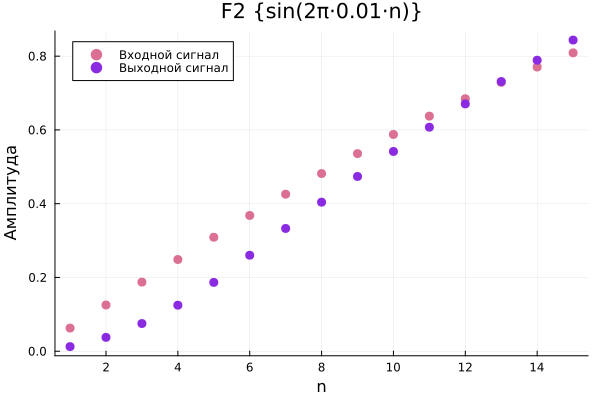

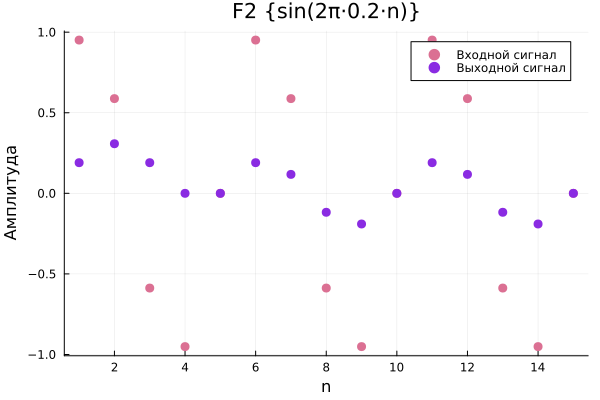

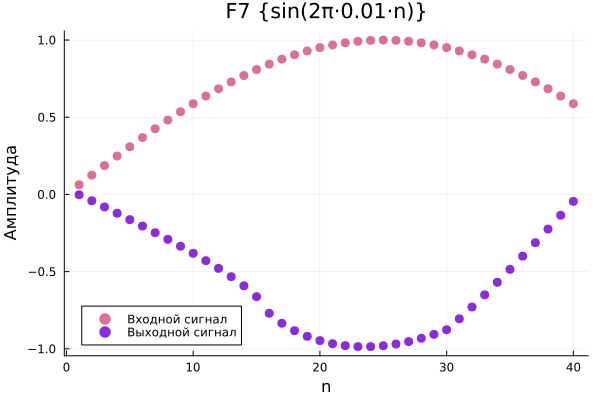

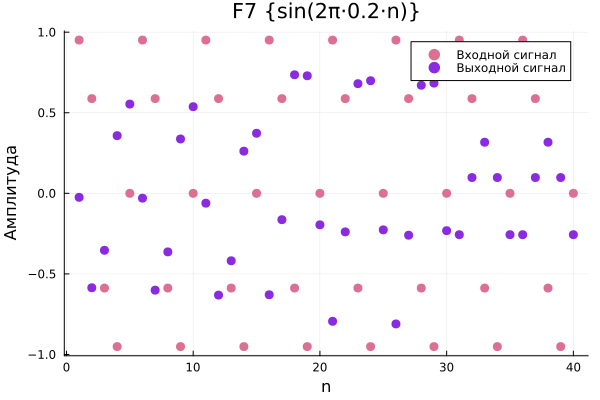

In [233]:

function x1_F(n_max)
    x1_f = zeros(n_max)
    for n in 1:n_max
        x1_f[n] = sin(2*pi*0.01*n)
    end
    return x1_f
end

function x2_F(n_max)
    x2_f = zeros(n_max)
    for n in 1:n_max
        x2_f[n] = sin(2*pi*0.2*n)
    end
    return x2_f
end

function compare_signals(x, y, title)
    n = 1:length(x)

    p = scatter(n, x,label="Входной сигнал",xlabel="n",ylabel="Амплитуда",
        title=title, markerstrokewidth = 0, markersize = 5, color=:palevioletred)

    scatter!(p, n, y,label="Выходной сигнал",markerstrokewidth = 0, markersize = 5, color=:blueviolet)

    display(p)
end
x1,x2 = x1_F(15),x2_F(15) 
F2_x1 = F2(x1)
F2_x2 = F2(x2_F(15))

compare_signals(x1, F2_x1, "F2 {sin(2π⋅0.01⋅n)}")
compare_signals(x2, F2_x2, "F2 {sin(2π⋅0.2⋅n)}")

x1,x2 = x1_F(40),x2_F(40) 
F7_x1 = F7(x1)
F7_x2 = F7(x2)
compare_signals(x1, F7_x1, "F7 {sin(2π⋅0.01⋅n)}")
compare_signals(x2, F7_x2, "F7 {sin(2π⋅0.2⋅n)}")